In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [ ]:
# 1. Precos (Mensais)
df = yf.download("PETR4.SA", start="2011-12-01", end="2026-02-01", auto_adjust=True)
precos = df.iloc[:, 0].resample('M').last()
display(precos)

[*********************100%***********************]  1 of 1 completed
C:\Users\thiag\AppData\Local\Temp\ipykernel_25360\655557305.py:3: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  precos = df.iloc[:, 0].resample('w').last()


Date
2011-12-04     5.277105
2011-12-11     5.391875
2011-12-18     4.989006
2011-12-25     5.204494
2012-01-01     5.033510
                ...    
2026-01-04    30.709999
2026-01-11    30.299999
2026-01-18    32.040001
2026-01-25    35.040001
2026-02-01    37.759998
Freq: W-SUN, Name: (Close, PETR4.SA), Length: 740, dtype: float64

In [9]:
# 2. Retornos
dados = pd.DataFrame({'Preco': precos})
dados['Retorno_Simples'] = dados['Preco'].pct_change()
dados['Log_Return'] = np.log(dados['Preco'] / dados['Preco'].shift(1))
dados = dados.loc['2010-12-31':].dropna()
display(dados)

,Preco,Retorno_Simples,Log_Return
Date,,,
2011-12-11,5.391875,0.021749,0.021516
2011-12-18,4.989006,-0.074718,-0.077657
2011-12-25,5.204494,0.043193,0.042286
2012-01-01,5.033510,-0.032853,-0.033405
2012-01-08,5.273286,0.047636,0.046536
...,...,...,...
2026-01-04,30.709999,0.009865,0.009817
2026-01-11,30.299999,-0.013351,-0.013441
2026-01-18,32.040001,0.057426,0.055837


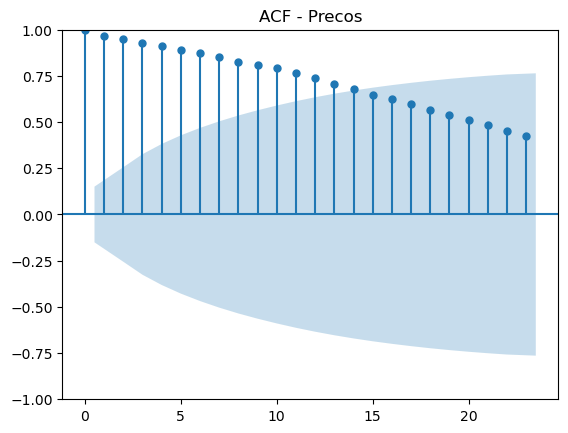

In [79]:
# 3. ACF Precos
plot_acf(dados['Preco'], title='ACF - Precos')
plt.show()

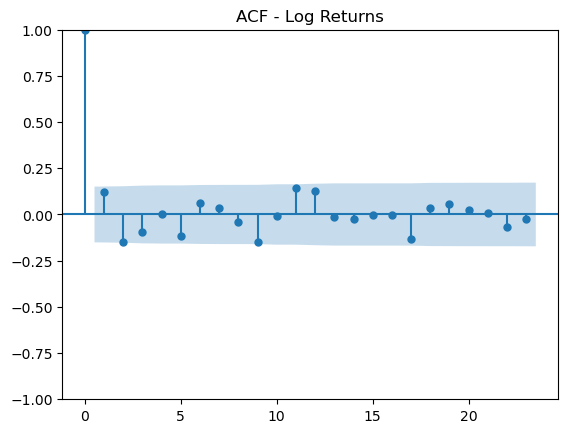

In [80]:
# 4. ACF Log Returns
plot_acf(dados['Log_Return'], title='ACF - Log Returns')
plt.show()

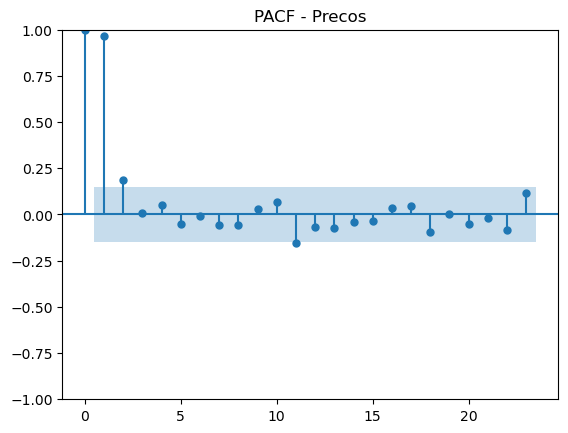

In [73]:
# 5. PACF Precos
plot_pacf(dados['Preco'], title='PACF - Precos')
plt.show()

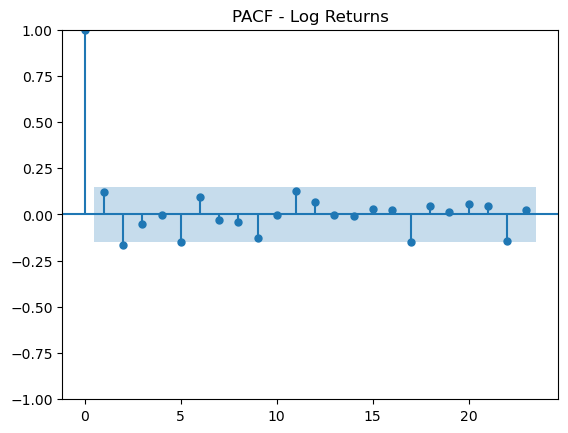

In [74]:
# 6. PACF Log Returns
plot_pacf(dados['Log_Return'], title='PACF - Log Returns',)
plt.show()

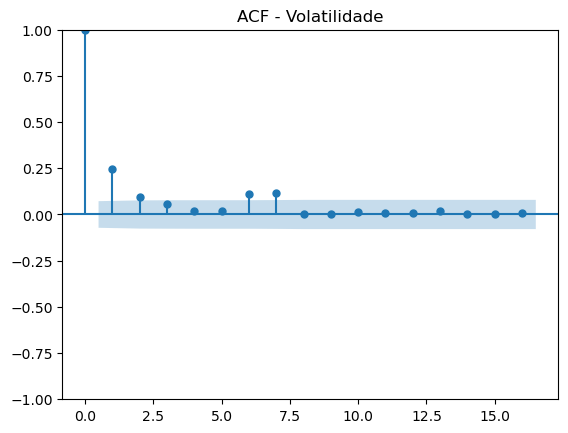

In [ ]:
# 7. ACF Volatilidade
plot_acf(dados['Log_Return']**2, title='ACF - Volatilidade')
plt.show()

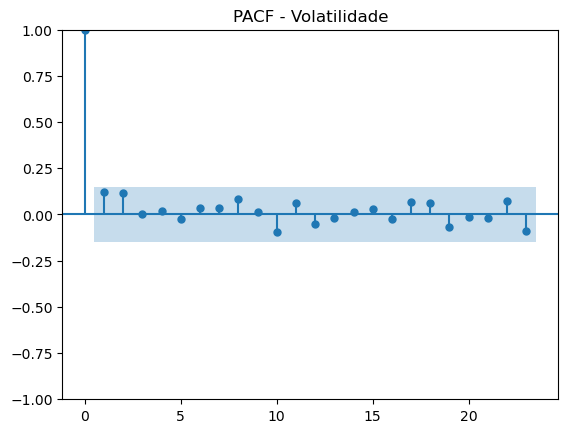

In [76]:
# 8. PACF Volatilidade
plot_pacf(dados['Log_Return']**2, title='PACF - Volatilidade')
plt.show()